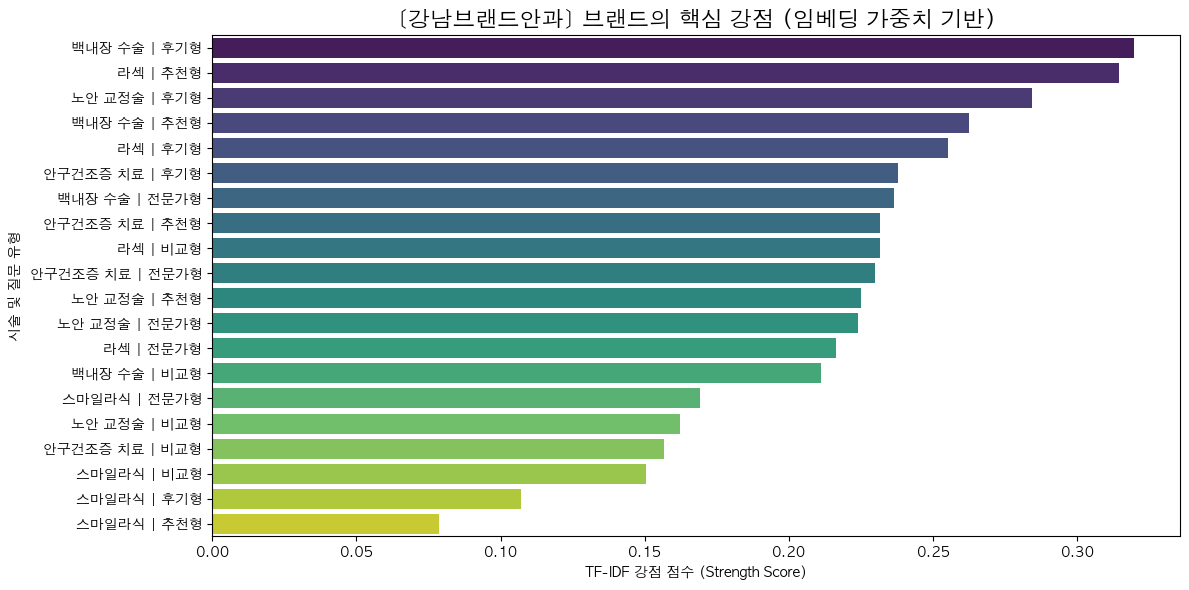

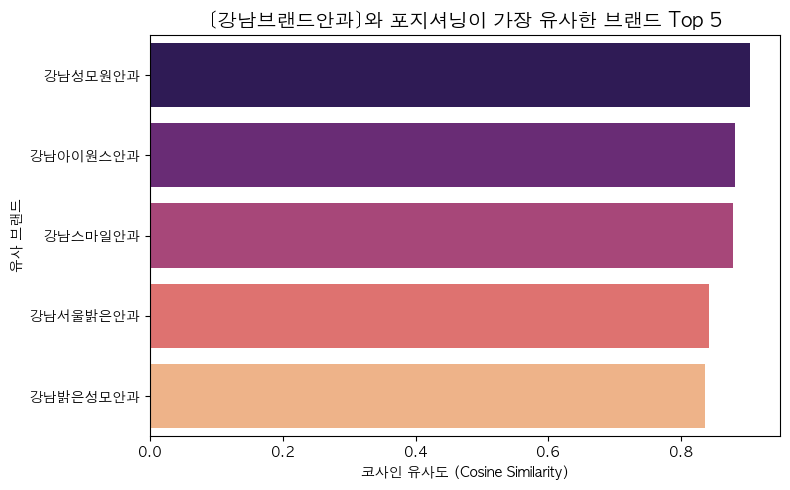

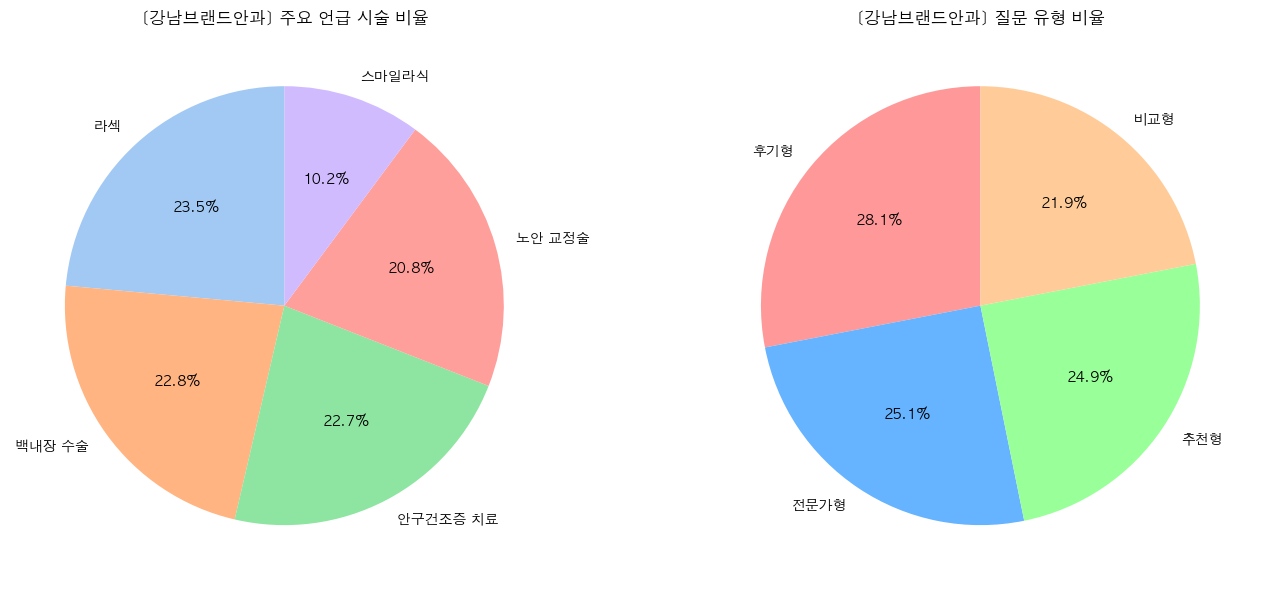

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.metrics.pairwise import cosine_similarity
import warnings

warnings.filterwarnings('ignore')

# macOS 및 Windows 한글 폰트 설정
plt.rc('font', family='AppleGothic') # Windows는 'Malgun Gothic' 적용
plt.rcParams['axes.unicode_minus'] = False

# =========================================================
# 🎯 분석 타겟 설정 ('안과'가 붙은 최종 이름으로 입력하세요!)
# =========================================================
TARGET_BRAND = '강남브랜드안과' 

# ---------------------------------------------------------
# 1. 파일 로드 및 전처리 ('안과' 자동 부착 + Explode)
# ---------------------------------------------------------
df = pd.read_csv('geo_unif_preprocessed_final_polished.csv')

# 이름 끝에 '안과'가 없으면 자동으로 붙여주는 함수
def append_eye_clinic(brand_str):
    if pd.isna(brand_str):
        return brand_str
    brands = [b.strip() for b in str(brand_str).split(',')]
    processed_brands = [b + '안과' if not b.endswith('안과') else b for b in brands]
    return ', '.join(processed_brands)

# 파일 저장 없이 메모리에서 바로 덮어쓰기 적용!
df['recommended_list'] = df['recommended_list'].apply(append_eye_clinic)

# 분석용 컬럼명 매핑
column_mapping = {
    'query_type': '유형',
    'recommended_list': '언급된 브랜드'
}
df = df.rename(columns=column_mapping)
df_clean = df.dropna(subset=['언급된 브랜드']).copy()

# 쉼표 기준으로 분리 후 Explode, 중복 인덱스 에러 방지용 reset_index
df_clean['브랜드_리스트'] = df_clean['언급된 브랜드'].apply(lambda x: [brand.strip() for brand in str(x).split(',')])
df_exploded = df_clean.explode('브랜드_리스트').rename(columns={'브랜드_리스트': '브랜드'}).reset_index(drop=True)

# ---------------------------------------------------------
# 2. 브랜드 임베딩 (Feature Vector 구축)
# ---------------------------------------------------------
df_exploded['context_feature'] = df_exploded['procedure'] + " | " + df_exploded['유형']

# 빈도 행렬 생성
pivot_df = pd.crosstab(df_exploded['브랜드'], df_exploded['context_feature'])

# TF-IDF 변환
tfidf = TfidfTransformer()
brand_embeddings = tfidf.fit_transform(pivot_df).toarray()
embedding_df = pd.DataFrame(brand_embeddings, index=pivot_df.index, columns=pivot_df.columns)

# ---------------------------------------------------------
# 3. 분석 결과 시각화
# ---------------------------------------------------------
if TARGET_BRAND not in embedding_df.index:
    print(f"\n❌ 데이터에 '{TARGET_BRAND}' 브랜드가 존재하지 않습니다.")
    print("사용 가능한 상위 브랜드 목록:", df_exploded['브랜드'].value_counts().index[:10].tolist(), "...")
else:
    # 3-1) 특정 브랜드 집중 분석
    target_vector = embedding_df.loc[TARGET_BRAND]
    top_features = target_vector[target_vector > 0].sort_values(ascending=False)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
    plt.title(f'[{TARGET_BRAND}] 브랜드의 핵심 강점 (임베딩 가중치 기반)', fontsize=16)
    plt.xlabel('TF-IDF 강점 점수 (Strength Score)')
    plt.ylabel('시술 및 질문 유형')
    plt.tight_layout()
    plt.show()

    # 3-2) 경쟁/유사 브랜드 찾기
    similarity_matrix = cosine_similarity(embedding_df)
    similarity_df = pd.DataFrame(similarity_matrix, index=embedding_df.index, columns=embedding_df.index)
    
    top_similar_brands = similarity_df[TARGET_BRAND].drop(TARGET_BRAND).sort_values(ascending=False).head(5)
    
    plt.figure(figsize=(8, 5))
    sns.barplot(x=top_similar_brands.values, y=top_similar_brands.index, palette='magma')
    plt.title(f'[{TARGET_BRAND}]와 포지셔닝이 가장 유사한 브랜드 Top 5', fontsize=14)
    plt.xlabel('코사인 유사도 (Cosine Similarity)')
    plt.ylabel('유사 브랜드')
    plt.tight_layout()
    plt.show()

    # 3-3) 세부 비율 확인
    target_data = df_exploded[df_exploded['브랜드'] == TARGET_BRAND]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    procedure_counts = target_data['procedure'].value_counts()
    axes[0].pie(procedure_counts, labels=procedure_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
    axes[0].set_title(f'[{TARGET_BRAND}] 주요 언급 시술 비율')
    
    type_counts = target_data['유형'].value_counts()
    axes[1].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff', '#99ff99', '#ffcc99'])
    axes[1].set_title(f'[{TARGET_BRAND}] 질문 유형 비율')
    
    plt.tight_layout()
    plt.show()